In [1]:
#import Dataset
import pandas as pd
df=pd.read_csv("../dataset/creditcard.csv")
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [2]:
print("Shape:", df.shape)

Shape: (284807, 31)


In [3]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  fl

In [4]:
# Drop duplicate values
df= df.drop_duplicates()
print(df.shape)

(283726, 31)


In [5]:
#Missing values
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [6]:
print(df["Class"].value_counts())

Class
0    283253
1       473
Name: count, dtype: int64


In [7]:
print(
    (df["Class"].value_counts(normalize=True) * 100).round(4))

Class
0    99.8333
1     0.1667
Name: proportion, dtype: float64


In [8]:
#Removing Outlier
print("Transaction Amount Statistics:")
display(df["Amount"].describe())

# Quartiles and IQR
Q1 = df["Amount"].quantile(0.25)
Q3 = df["Amount"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

outliers = df[
        (df["Amount"] < lower_bound) |
    (df["Amount"] > upper_bound)
]

print("\nNumber of statistical outliers:", len(outliers))
print("Percentage of dataset:",
      round(len(outliers) / len(df) * 100, 4), "%")

Transaction Amount Statistics:


count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64

Q1: 5.6
Q3: 77.51
IQR: 71.91000000000001
Lower bound: -102.26500000000001
Upper bound: 185.375

Number of statistical outliers: 31685
Percentage of dataset: 11.1675 %


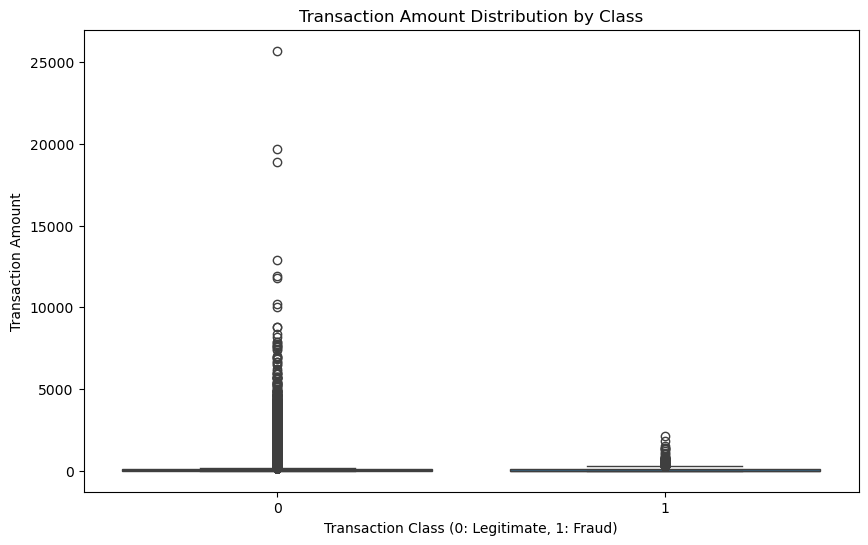

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount Distribution by Class")
plt.xlabel("Transaction Class (0: Legitimate, 1: Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

In [10]:
df = df[df["Amount"] <= 10000]
print(df.shape)

(283719, 31)


In [11]:
df["Hour"] = ((df["Time"] // 3600) % 24).astype(int)

print("Hour feature created.")
print("Minimum hour:", df["Hour"].min())
print("Maximum hour:", df["Hour"].max())

Hour feature created.
Minimum hour: 0
Maximum hour: 23


In [12]:
#Check fraud by hour
fraud_by_hour = (
    df[df["Class"] == 1]
    .groupby("Hour")
    .size()
    .sort_index()
)

display(fraud_by_hour)

Hour
0      6
1     10
2     48
3     17
4     23
5     11
6      9
7     23
8      9
9     16
10     8
11    53
12    17
13    17
14    23
15    26
16    22
17    28
18    28
19    19
20    18
21    16
22     9
23    17
dtype: int64

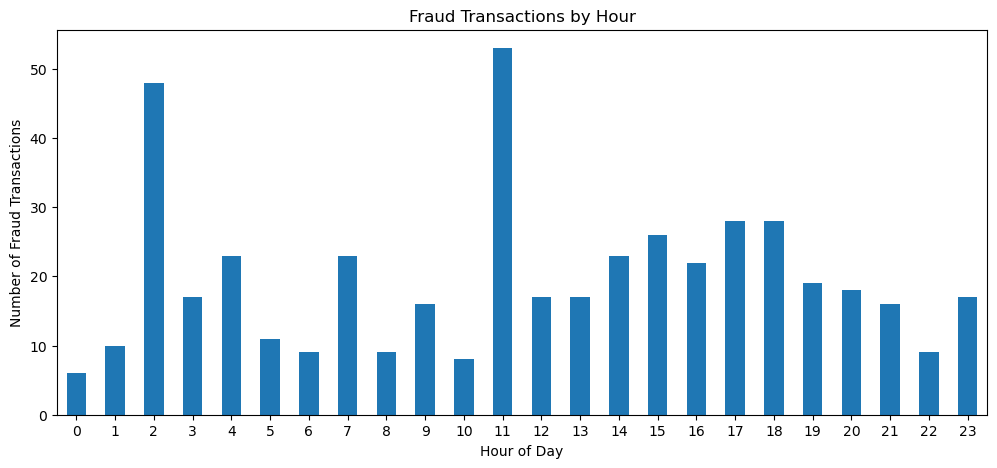

In [13]:
plt.figure(figsize=(12, 5))

fraud_by_hour.plot(kind="bar")

plt.title("Fraud Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Fraud Transactions")
plt.xticks(rotation=0)

plt.show()


In [14]:
correlations = (
    df.corr(numeric_only=True)["Class"]
    .drop("Class")
    .sort_values(key=abs, ascending=False)
)

display(correlations)

V17      -0.313542
V14      -0.293443
V12      -0.250765
V10      -0.207119
V16      -0.187323
V3       -0.182904
V7       -0.176145
V11       0.149082
V4        0.129462
V18      -0.105355
V1       -0.094736
V9       -0.094029
V5       -0.089160
V2        0.085351
V6       -0.044172
V19       0.033644
V8        0.033098
V21       0.026442
V27       0.022164
V20       0.022022
Hour     -0.016741
Time     -0.012359
V28       0.009725
V24      -0.007209
V23      -0.006375
Amount    0.006187
V22       0.004887
V26       0.004265
V13      -0.003895
V15      -0.003297
V25       0.003201
Name: Class, dtype: float64

In [15]:
print(df.shape)

(283719, 32)


In [16]:
X = df.drop(columns=["Class"])  # or whatever your target column is named
y = df["Class"]

In [17]:
#Undersampling
from imblearn.under_sampling import RandomUnderSampler

# 1. Define X and y
X = df.drop(columns=["Class"])
y = df["Class"]

# 2. Undersample Non-Fraud (0) down to 50,000 samples
# 'sampling_strategy' accepts a dictionary mapping class label -> desired count
rus = RandomUnderSampler(sampling_strategy={0: 100000}, random_state=42)
X_under, y_under = rus.fit_resample(X, y)

print("Class distribution after Undersampling:")
print(y_under.value_counts())

Class distribution after Undersampling:
Class
0    100000
1       473
Name: count, dtype: int64


In [18]:
from imblearn.over_sampling import SMOTE

# Oversample Fraud (1) so Fraud is exactly 5% (1/20) of Non-Fraud
# sampling_strategy = 0.05 sets Fraud count = 0.05 * Non-Fraud count
smote = SMOTE(sampling_strategy=0.025, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_under, y_under)

print("Final Class distribution")
print(y_resampled.value_counts())

c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

Final Class distribution
Class
0    100000
1      2500
Name: count, dtype: int64


In [19]:
from sklearn.preprocessing import MinMaxScaler

# 1. Recombine feature matrix and target series into a single DataFrame
df = pd.DataFrame(X_resampled, columns=X.columns)
df["Class"] = y_resampled.values

# 2. Separate features to be normalized (excluding target 'Class')
feature_cols = [col for col in df.columns if col != "Class"]

# 3. Apply MinMaxScaler to bring all feature values into the range [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
df[feature_cols] = scaler.fit_transform(df[feature_cols])

# Display the first few rows of the updated df
print("DataFrame updated with normalized features [0, 1]:")
print(df.head())

DataFrame updated with normalized features [0, 1]:
       Time        V1        V2        V3        V4        V5        V6  \
0  0.297200  0.938723  0.778524  0.918136  0.221880  0.499993  0.538031   
1  0.940319  0.948151  0.773497  0.929144  0.240171  0.508966  0.553399   
2  0.371390  0.980520  0.759822  0.912290  0.212270  0.488044  0.554094   
3  0.981370  0.991556  0.771292  0.812271  0.292028  0.532139  0.565432   
4  0.362171  0.942091  0.766260  0.913371  0.198613  0.500701  0.538675   

         V7        V8        V9  ...       V22       V23       V24       V25  \
0  0.548223  0.714617  0.574636  ...  0.532327  0.611716  0.429848  0.480839   
1  0.546557  0.723744  0.566134  ...  0.486434  0.615376  0.494966  0.469687   
2  0.527245  0.720695  0.532701  ...  0.590408  0.611524  0.379806  0.525729   
3  0.547858  0.720412  0.549277  ...  0.553346  0.613275  0.258283  0.526438   
4  0.558400  0.717366  0.546370  ...  0.513099  0.617651  0.421162  0.509290   

        V26      

In [20]:
from sklearn.model_selection import train_test_split

# 1. Separate features (X) and target variable (y) from the normalized df
X = df.drop(columns=["Class"])
y = df["Class"]

# 2. Perform train-test split (80% train, 20% test)
# stratify=y preserves the exact class ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# 3. Check split sizes
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape:  {X_test.shape}")
print("\nTraining Class Distribution:")
print(y_train.value_counts())

Training features shape: (82000, 31)
Testing features shape:  (20500, 31)

Training Class Distribution:
Class
0    80000
1     2000
Name: count, dtype: int64


In [21]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [22]:
#XGboost Model
from xgboost import XGBClassifier

# 1. Initialize the XGBClassifier
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
)

# 2. Train the model on your training dataset
model.fit(X_train, y_train)

# 3. Predict class probabilities on the test set
# predict_proba returns [prob_non_fraud, prob_fraud]
probabilities = model.predict_proba(X_test)

# 4. Display predicted percentage probabilities alongside actual test labels
results = pd.DataFrame(
    {
        "Non_Fraud_%": (probabilities[:, 0] * 100).round(2),
        "Fraud_%": (probabilities[:, 1] * 100).round(2),
        "Actual_Class": y_test.values,
    }
)

print("Sample Predictions:")
print(results.head(10))

Sample Predictions:
   Non_Fraud_%    Fraud_%  Actual_Class
0    99.989998   0.010000             0
1   100.000000   0.000000             0
2    99.989998   0.010000             0
3    99.269997   0.730000             0
4    99.919998   0.080000             0
5    58.619999  41.380001             1
6    99.989998   0.010000             0
7   100.000000   0.000000             0
8   100.000000   0.000000             0
9   100.000000   0.000000             0


In [23]:
from sklearn.metrics import classification_report, roc_auc_score

# Hard predictions (50% threshold)
y_pred = model.predict(X_test)

# Fraud probabilities
y_proba_fraud = probabilities[:, 1]

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_fraud):.4f}")

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20000
           1       0.98      0.95      0.97       500

    accuracy                           1.00     20500
   macro avg       0.99      0.97      0.98     20500
weighted avg       1.00      1.00      1.00     20500

ROC-AUC Score: 0.9990


In [24]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
)

# 2. Train the model on scaled training data
rf_model.fit(X_train, y_train)

# 3. Predict class probabilities on test set
# probabilities[:, 0] = % Non-Fraud, probabilities[:, 1] = % Fraud
rf_probabilities = rf_model.predict_proba(X_test)

# 4. Format sample predictions into percentages
rf_results = pd.DataFrame(
    {
        "Non_Fraud_%": (rf_probabilities[:, 0] * 100).round(2),
        "Fraud_%": (rf_probabilities[:, 1] * 100).round(2),
        "Actual_Class": y_test.values,
    }
)

print("Sample Random Forest Predictions:")
print(rf_results.head(10))

# 5. Evaluate Performance
y_pred_rf = rf_model.predict(X_test)
y_proba_fraud_rf = rf_probabilities[:, 1]

print("\n--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf))

print(f"Random Forest ROC-AUC Score: {roc_auc_score(y_test, y_proba_fraud_rf):.4f}")

Sample Random Forest Predictions:
   Non_Fraud_%  Fraud_%  Actual_Class
0        99.90     0.10             0
1        99.84     0.16             0
2        99.88     0.12             0
3        81.37    18.63             0
4        99.89     0.11             0
5        99.66     0.34             1
6        99.90     0.10             0
7        99.89     0.11             0
8        99.90     0.10             0
9        99.85     0.15             0

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20000
           1       0.99      0.89      0.94       500

    accuracy                           1.00     20500
   macro avg       0.99      0.95      0.97     20500
weighted avg       1.00      1.00      1.00     20500

Random Forest ROC-AUC Score: 0.9954


In [26]:
import joblib

# Save trained XGBoost model
joblib.dump(model, "../model/xgboost_fraud_classifier.pkl")

['../model/xgboost_fraud_classifier.pkl']